# Week 9: Transfer Learning

**October 13:** Fall Break — no class  
**Lecture 15 — October 15:** Transfer Learning

Transfer learning starts from representations learned on a large source dataset and adapts them to a target task. We compare the same ResNet-18 architecture under three initialization and training strategies: training from scratch, frozen feature extraction, and fine-tuning.

## Learning goals

By the end of the lecture, you should be able to:

- explain why representations learned on ImageNet can transfer;
- replace a pretrained classifier for a new label space;
- distinguish feature extraction from fine-tuning;
- control trainable parameters with `requires_grad`;
- handle normalization and BatchNorm correctly while freezing layers;
- use smaller, discriminative learning rates when fine-tuning; and
- recognize domain shift and negative transfer.

In [1]:
from copy import deepcopy
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA is unavailable; full training will be slow.")

PyTorch version: 2.11.0+cu128
device: cuda
GPU: NVIDIA GeForce RTX 3090


## Data and pretrained preprocessing

The pretrained weights were learned from ImageNet images normalized with the ImageNet channel means and standard deviations. Matching that preprocessing is part of using the weights correctly. The training pipeline adds random crops, flips, and RandAugment; validation is deterministic.

The dataset remains outside the repository at `../../datasets/imagenette2`. Imagenette is especially convenient here: its ten classes are drawn from ImageNet, so it represents a favorable, low-domain-shift transfer setting.

In [2]:
# Paths are relative to this notebook's Week 9 directory.
DATA_ROOT = Path("../../datasets/imagenette2")
CHECKPOINT_DIRECTORY = Path("checkpoints")
CHECKPOINT_DIRECTORY.mkdir(parents=True, exist_ok=True)
IMAGE_SIZE = 224
BATCH_SIZE = 64
SCRATCH_EPOCHS = 40
FEATURE_EXTRACTION_EPOCHS = 15
FINE_TUNING_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 6
MINIMUM_IMPROVEMENT = 1e-4

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)
# Augmentation supplies varied target-domain views during training.
training_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
# These normalization values match the source data used for pretraining.
evaluation_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
training_dataset = datasets.ImageFolder(DATA_ROOT / "train", training_transform)
validation_dataset = datasets.ImageFolder(DATA_ROOT / "val", evaluation_transform)
loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": 2,
    "pin_memory": device.type == "cuda",
    "persistent_workers": True,
}
training_loader = DataLoader(training_dataset, shuffle=True, **loader_options)
validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_options)
number_of_classes = len(training_dataset.classes)
print(f"training examples:   {len(training_dataset):,}")
print(f"validation examples: {len(validation_dataset):,}")
print("classes:", training_dataset.classes)

training examples:   9,469
validation examples: 3,925
classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']


## Three strategies

| Strategy | Initialization | Updated parameters | Typical use |
|---|---|---|---|
| From scratch | Random | Entire model | Large target dataset or very different domain |
| Feature extraction | Pretrained | New classifier only | Small target dataset, fast baseline |
| Fine-tuning | Pretrained | Some or all pretrained layers | More target data and a related domain |

Feature extraction treats the backbone as a fixed mapping $h=f_\theta(X)$ and learns only a target classifier $g_\phi(h)$. Fine-tuning also updates some of $\theta$, usually with a smaller step size so useful source features are not immediately destroyed.

## Constructing and freezing the model

Torchvision's weights object identifies both the learned parameters and their metadata. Replacing `model.fc` creates a new randomly initialized ten-class head. Freezing is controlled by `requires_grad`; the optimizer should receive only parameters that remain trainable.

Freezing weights does **not** automatically freeze BatchNorm running means and variances. During feature extraction, frozen BatchNorm modules are put in evaluation mode after `model.train()` so their pretrained statistics remain fixed.

In [3]:
def replace_resnet_classifier(model, number_of_classes):
    # Preserve the backbone output width while changing the target label count.
    model.fc = nn.Linear(model.fc.in_features, number_of_classes)
    return model


def set_trainable(module, trainable):
    # requires_grad controls whether autograd stores and computes parameter gradients.
    for parameter in module.parameters():
        parameter.requires_grad = trainable


def set_frozen_batch_norm_to_eval(model):
    # Frozen affine weights do not automatically freeze running mean and variance.
    for module in model.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            local_parameters = list(module.parameters(recurse=False))
            if local_parameters and not any(
                parameter.requires_grad for parameter in local_parameters
            ):
                module.eval()


def count_parameters(model):
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(
        parameter.numel() for parameter in model.parameters()
        if parameter.requires_grad
    )
    return trainable, total


def print_parameter_counts(label, model):
    trainable, total = count_parameters(model)
    print(f"{label:<24} {trainable:>12,} / {total:>12,} trainable / total")

## Shared training loop

All three experiments use the same data split, augmentation, loss, validation metric, early-stopping rule, and best-checkpoint behavior. This does not make the comparison scientifically exhaustive—the learning rates and epoch budgets appropriately differ by strategy—but it keeps the major evaluation choices controlled.

In [ ]:
def run_epoch(model, loader, loss_function, optimizer=None):
    # The same function evaluates when optimizer is omitted and trains otherwise.
    training = optimizer is not None
    model.train(training)
    if training:
        # Restore frozen BatchNorm layers to eval after model.train() changes all modes.
        set_frozen_batch_norm_to_eval(model)
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        if training:
            # Prevent gradients from accumulating across independent mini-batches.
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            logits = model(X)
            loss = loss_function(logits, y)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
        # Weight each batch by its size before computing the epoch average.
        total_loss += loss.item() * X.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_examples += X.size(0)
    return total_loss / total_examples, total_correct / total_examples


def fit_model(
    model, optimizer, scheduler, epochs, checkpoint_path,
    patience=EARLY_STOPPING_PATIENCE,
    minimum_improvement=MINIMUM_IMPROVEMENT,
):
    loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_state = deepcopy(model.state_dict())
    best_validation_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    history = []
    print(
        f"{'epoch':>7} {'loss':>11} {'val_loss':>11} "
        f"{'accuracy':>11} {'val_accuracy':>14} {'lr':>10}  status"
    )
    print("-" * 84)
    for epoch in range(1, epochs + 1):
        training_loss, training_accuracy = run_epoch(
            model, training_loader, loss_function, optimizer
        )
        validation_loss, validation_accuracy = run_epoch(
            model, validation_loader, loss_function
        )
        learning_rate = max(group["lr"] for group in optimizer.param_groups)
        improved = validation_loss < best_validation_loss - minimum_improvement
        status = (
            "best" if improved
            else f"wait {epochs_without_improvement + 1}/{patience}"
        )
        history.append({
            "epoch": epoch, "loss": training_loss,
            "val_loss": validation_loss, "accuracy": training_accuracy,
            "val_accuracy": validation_accuracy, "learning_rate": learning_rate,
        })
        print(
            f"{epoch:7d} {training_loss:11.5f} {validation_loss:11.5f} "
            f"{training_accuracy:11.4f} {validation_accuracy:14.4f} "
            f"{learning_rate:10.2e}  {status}"
        )
        scheduler.step()
        if improved:
            # Keep the state that generalized best, even if later epochs overfit.
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
            torch.save({
                "epoch": epoch, "model_state_dict": best_state,
                "validation_loss": validation_loss,
                "validation_accuracy": validation_accuracy,
                "history": history,
            }, checkpoint_path)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}.")
                break
    model.load_state_dict(best_state)
    print(f"Restored epoch {best_epoch}; checkpoint: {checkpoint_path}")
    return history

## Experiment 1: train from scratch

This is the control condition. The ResNet-18 architecture is identical, but every parameter begins randomly initialized and must be learned from 9,469 Imagenette training images. It receives the largest epoch budget.

In [5]:
# weights=None gives the control model no information from ImageNet.
scratch_model = replace_resnet_classifier(
    models.resnet18(weights=None), number_of_classes
).to(device)
print_parameter_counts("from scratch", scratch_model)
scratch_optimizer = torch.optim.AdamW(
    scratch_model.parameters(), lr=3e-4, weight_decay=1e-4
)
scratch_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    scratch_optimizer, T_max=SCRATCH_EPOCHS
)
scratch_history = fit_model(
    scratch_model, scratch_optimizer, scratch_scheduler, SCRATCH_EPOCHS,
    CHECKPOINT_DIRECTORY / "week9_resnet18_scratch_best.pt",
)

from scratch               11,181,642 /   11,181,642 trainable / total
  epoch        loss    val_loss    accuracy   val_accuracy         lr  status
------------------------------------------------------------------------------------
      1     1.78774     1.51406      0.4449         0.5676   3.00e-04  best
      2     1.45392     1.39794      0.6033         0.6153   3.00e-04  best
      3     1.32490     1.29820      0.6605         0.6627   2.98e-04  best
      4     1.23948     1.31734      0.6955         0.6670   2.96e-04  wait 1/6
      5     1.17268     1.27104      0.7245         0.6938   2.93e-04  best
      6     1.12079     1.10689      0.7459         0.7587   2.89e-04  best
      7     1.08672     1.11567      0.7597         0.7442   2.84e-04  wait 1/6
      8     1.04507     1.06819      0.7821         0.7689   2.78e-04  best
      9     1.01343     1.11142      0.7941         0.7485   2.71e-04  wait 1/6
     10     0.97892     1.14177      0.8088         0.7368   2.64e-04 

## Experiment 2: frozen feature extraction

The ImageNet backbone is frozen and only the new classifier is optimized. This is cheap: activations still pass through the backbone, but autograd does not store a backward graph for its parameters. A larger learning rate is reasonable for the newly initialized head.

The first use of pretrained weights may download them into PyTorch's local cache.

In [6]:
# DEFAULT selects torchvision's recommended pretrained ResNet-18 weights.
weights = models.ResNet18_Weights.DEFAULT
feature_model = models.resnet18(weights=weights)
# Freeze the entire pretrained network before installing a new trainable head.
set_trainable(feature_model, False)
feature_model = replace_resnet_classifier(feature_model, number_of_classes).to(device)
print_parameter_counts("feature extraction", feature_model)
feature_optimizer = torch.optim.AdamW(
    feature_model.fc.parameters(), lr=1e-3, weight_decay=1e-4
)
feature_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    feature_optimizer, T_max=FEATURE_EXTRACTION_EPOCHS
)
feature_history = fit_model(
    feature_model, feature_optimizer, feature_scheduler,
    FEATURE_EXTRACTION_EPOCHS,
    CHECKPOINT_DIRECTORY / "week9_resnet18_feature_best.pt",
)

feature extraction              5,130 /   11,181,642 trainable / total
  epoch        loss    val_loss    accuracy   val_accuracy         lr  status
------------------------------------------------------------------------------------
      1     0.87477     0.65288      0.8944         0.9763   1.00e-03  best
      2     0.67040     0.63734      0.9665         0.9817   9.89e-04  best
      3     0.66274     0.62607      0.9702         0.9847   9.57e-04  best
      4     0.65040     0.62492      0.9720         0.9822   9.05e-04  best
      5     0.64717     0.61976      0.9743         0.9845   8.35e-04  best
      6     0.64419     0.61850      0.9757         0.9845   7.50e-04  best
      7     0.64123     0.61818      0.9761         0.9857   6.55e-04  best
      8     0.63765     0.61677      0.9785         0.9865   5.52e-04  best
      9     0.63460     0.61401      0.9778         0.9842   4.48e-04  best
     10     0.63382     0.61490      0.9776         0.9845   3.45e-04  wait 1/6
  

## Experiment 3: fine-tune the last residual stage

Fine-tuning continues from the best feature-extraction model. `layer4` is unfrozen while earlier stages remain fixed. The pretrained residual stage receives a smaller learning rate than the classifier head:

$$\alpha_{\text{layer4}} < \alpha_{\text{head}}.$$

These **discriminative learning rates** let the new head adapt quickly while changing useful pretrained features cautiously. Unfreezing more stages can help when there is enough target data, but increases compute and the risk of overfitting or catastrophic forgetting.

In [7]:
# Continue from the best feature-extraction weights already restored by fit_model.
fine_tune_model = feature_model
set_trainable(fine_tune_model, False)
set_trainable(fine_tune_model.layer4, True)
set_trainable(fine_tune_model.fc, True)
print_parameter_counts("fine-tuning layer4", fine_tune_model)
# Parameter groups give the pretrained stage a smaller step than the new head.
fine_tune_optimizer = torch.optim.AdamW([
    {"params": fine_tune_model.layer4.parameters(), "lr": 1e-4},
    {"params": fine_tune_model.fc.parameters(), "lr": 5e-4},
], weight_decay=1e-4)
fine_tune_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    fine_tune_optimizer, T_max=FINE_TUNING_EPOCHS
)
fine_tune_history = fit_model(
    fine_tune_model, fine_tune_optimizer, fine_tune_scheduler,
    FINE_TUNING_EPOCHS,
    CHECKPOINT_DIRECTORY / "week9_resnet18_fine_tuned_best.pt",
)

fine-tuning layer4          8,398,858 /   11,181,642 trainable / total
  epoch        loss    val_loss    accuracy   val_accuracy         lr  status
------------------------------------------------------------------------------------
      1     0.65731     0.61466      0.9668         0.9842   5.00e-04  best
      2     0.61280     0.60540      0.9799         0.9811   4.97e-04  best
      3     0.58906     0.59362      0.9871         0.9804   4.88e-04  best
      4     0.57820     0.59069      0.9901         0.9811   4.73e-04  best
      5     0.56711     0.58240      0.9920         0.9832   4.52e-04  best
      6     0.56228     0.58239      0.9938         0.9832   4.27e-04  wait 1/6
      7     0.55780     0.57862      0.9937         0.9829   3.97e-04  best
      8     0.55291     0.57226      0.9945         0.9855   3.63e-04  best
      9     0.54690     0.57240      0.9968         0.9850   3.27e-04  wait 1/6
     10     0.54227     0.57266      0.9971         0.9842   2.89e-04  wai

## Compare the learning curves

Feature extraction should begin with substantially better validation performance and converge quickly. Fine-tuning may improve the pretrained baseline further. The scratch model often needs more updates before it learns useful low-level features. Compare best validation performance, convergence speed, trainable parameter count, and wall-clock cost—not only the last epoch.

strategy                best val loss   best val acc
----------------------------------------------------
scratch                       0.76967         0.8968
feature extraction            0.61190         0.9865
fine-tuning                   0.56356         0.9855


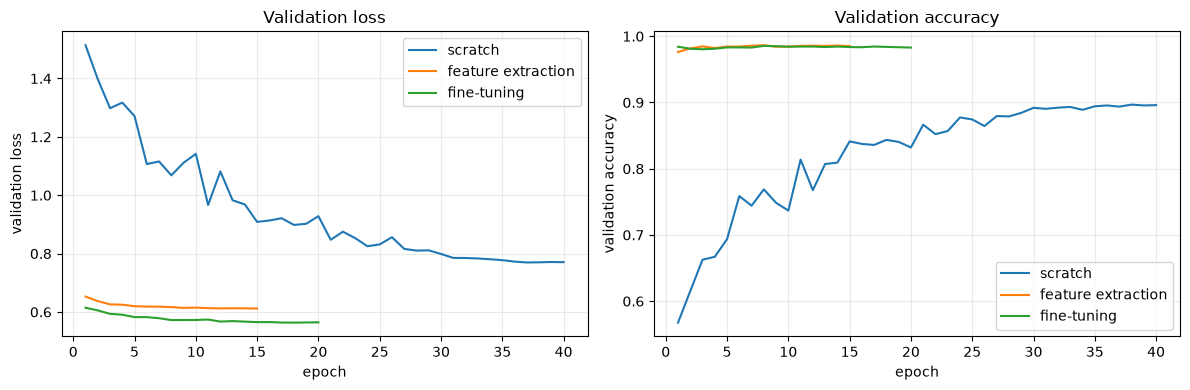

In [8]:
# A shared structure makes all three strategies easy to plot identically.
histories = {
    "scratch": scratch_history,
    "feature extraction": feature_history,
    "fine-tuning": fine_tune_history,
}
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, history in histories.items():
    epochs = [row["epoch"] for row in history]
    axes[0].plot(epochs, [row["val_loss"] for row in history], label=label)
    axes[1].plot(epochs, [row["val_accuracy"] for row in history], label=label)
axes[0].set(xlabel="epoch", ylabel="validation loss", title="Validation loss")
axes[1].set(xlabel="epoch", ylabel="validation accuracy", title="Validation accuracy")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
figure.tight_layout()

print(f"{'strategy':<22} {'best val loss':>14} {'best val acc':>14}")
print("-" * 52)
for label, history in histories.items():
    print(
        f"{label:<22} {min(row['val_loss'] for row in history):>14.5f} "
        f"{max(row['val_accuracy'] for row in history):>14.4f}"
    )

## Class-level evaluation

The fine-tuned model is evaluated by class below. Imagenette2 has no labeled test folder, and the validation split selected our checkpoints and hyperparameters. These results therefore describe validation behavior, not an unbiased final test estimate.

              precision    recall  f1-score   support

   n01440764       0.99      0.99      0.99       387
   n02102040       0.99      0.99      0.99       395
   n02979186       0.98      0.99      0.98       357
   n03000684       0.96      0.96      0.96       386
   n03028079       0.99      0.99      0.99       409
   n03394916       0.97      0.99      0.98       394
   n03417042       0.99      0.98      0.99       389
   n03425413       0.98      0.97      0.97       419
   n03445777       0.99      0.99      0.99       399
   n03888257       0.99      0.97      0.98       390

    accuracy                           0.98      3925
   macro avg       0.98      0.98      0.98      3925
weighted avg       0.98      0.98      0.98      3925



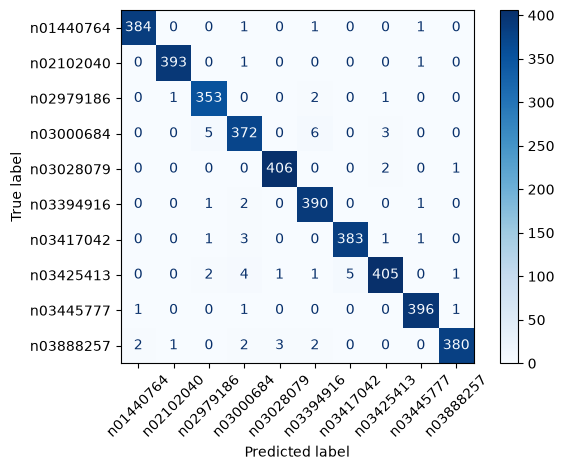

In [9]:
@torch.no_grad()
def predict_labels(model, loader):
    model.eval()
    true_labels = []
    predicted_labels = []
    for X, y in loader:
        logits = model(X.to(device, non_blocking=True))
        true_labels.extend(y.numpy())
        predicted_labels.extend(logits.argmax(dim=1).cpu().numpy())
    return np.asarray(true_labels), np.asarray(predicted_labels)

# Evaluate the restored fine-tuned checkpoint without building gradient graphs.
true_labels, predicted_labels = predict_labels(
    fine_tune_model, validation_loader
)
print(classification_report(
    true_labels, predicted_labels,
    labels=range(number_of_classes),
    target_names=validation_dataset.classes,
    zero_division=0,
))
ConfusionMatrixDisplay.from_predictions(
    true_labels, predicted_labels, labels=range(number_of_classes),
    display_labels=validation_dataset.classes,
    xticks_rotation=45, cmap="Blues",
)
plt.tight_layout()

## Domain shift and negative transfer

Transfer works best when source and target tasks share useful visual structure. Imagenette is extremely close to ImageNet, so strong transfer is expected. A target domain such as medical scans, satellite radar, or line drawings differs more in texture, color, scale, and semantics. Under substantial domain shift:

- the frozen representation may omit target-relevant information;
- unfreezing more layers may become necessary;
- source normalization may no longer be optimal;
- self-supervised pretraining on in-domain unlabeled data may help; and
- transfer can occasionally underperform a suitable model trained from scratch—**negative transfer**.

Always compare against a scratch baseline rather than assuming pretraining must help.

## Supplementary: Ensembling Built-in Pretrained Models

An ensemble combines predictions from multiple fitted models. For $M$ classifiers, probability soft voting computes

$$\bar p(y=c\mid X)=\frac{1}{M}\sum_{m=1}^{M}p_m(y=c\mid X), \qquad \hat y=\arg\max_c \bar p(y=c\mid X).$$

Averaging probabilities preserves each model's full uncertainty instead of using only its winning class. An ensemble helps when its members are individually useful and make different errors. Adding nearly identical models provides little benefit; adding a weak or badly calibrated model can make the result worse.

The experiment below uses ImageNet-pretrained ResNet-18, DenseNet-121, EfficientNet-B0, and ConvNeXt-Tiny models provided directly by torchvision. Their original classifiers already predict 1,000 ImageNet classes. Because Imagenette contains ten of those exact classes, no additional training is required: select the corresponding ten logits, normalize them into probabilities, and ensemble the results.

Each model is loaded and evaluated one at a time, and its probabilities are moved to CPU. This keeps GPU memory nearly constant as the ensemble grows. The first run may download the built-in weight files into PyTorch's cache.

In [ ]:
# ImageNet class indices corresponding to ImageFolder's sorted Imagenette labels.
imagenette_imagenet_indices = torch.tensor([
    0,    # tench
    217,  # English springer
    482,  # cassette player
    491,  # chain saw
    497,  # church
    566,  # French horn
    569,  # garbage truck
    571,  # gas pump
    574,  # golf ball
    701,  # parachute
])

pretrained_model_builders = {
    "resnet18": lambda: models.resnet18(
        weights=models.ResNet18_Weights.DEFAULT
    ),
    "densenet121": lambda: models.densenet121(
        weights=models.DenseNet121_Weights.DEFAULT
    ),
    "efficientnet_b0": lambda: models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.DEFAULT
    ),
    "convnext_tiny": lambda: models.convnext_tiny(
        weights=models.ConvNeXt_Tiny_Weights.DEFAULT
    ),
}


@torch.no_grad()
def collect_imagenette_probabilities(model, loader):
    model.eval()
    probability_batches = []
    label_batches = []
    selected_indices = imagenette_imagenet_indices.to(device)
    for X, y in loader:
        imagenet_logits = model(X.to(device, non_blocking=True))
        # Restrict the 1,000 source classes to Imagenette's ten target classes.
        selected_logits = imagenet_logits.index_select(1, selected_indices)
        probability_batches.append(torch.softmax(selected_logits, dim=1).cpu())
        label_batches.append(y.cpu())
    return torch.cat(probability_batches), torch.cat(label_batches)


pretrained_probabilities = {}
pretrained_predictions = {}
ensemble_rows = []
true_labels = None

for model_name, model_builder in pretrained_model_builders.items():
    model = model_builder().to(device)
    probabilities, labels = collect_imagenette_probabilities(
        model, validation_loader
    )
    predictions = probabilities.argmax(dim=1)
    accuracy = (predictions == labels).float().mean().item()
    pretrained_probabilities[model_name] = probabilities
    pretrained_predictions[model_name] = predictions
    true_labels = labels if true_labels is None else true_labels
    ensemble_rows.append({"model": model_name, "accuracy": accuracy})
    # Only CPU probabilities remain after this pretrained model is released.
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

average_probabilities = torch.stack(
    list(pretrained_probabilities.values())
).mean(dim=0)
ensemble_predictions = average_probabilities.argmax(dim=1)
ensemble_accuracy = (
    (ensemble_predictions == true_labels).float().mean().item()
)
ensemble_rows.append({
    "model": "soft-voting ensemble", "accuracy": ensemble_accuracy
})
ensemble_results = pd.DataFrame(ensemble_rows).set_index("model")
display(ensemble_results.style.format({"accuracy": "{:.4f}"}))

### Does the ensemble contain diverse models?

Pairwise disagreement is the fraction of validation examples for which two models predict different classes. It does not measure accuracy, but it reveals whether different architecture families offer meaningfully different decision boundaries.

In [ ]:
model_names = list(pretrained_predictions)
disagreement = pd.DataFrame(
    np.zeros((len(model_names), len(model_names))),
    index=model_names, columns=model_names,
)
for row_name in model_names:
    for column_name in model_names:
        disagreement.loc[row_name, column_name] = (
            pretrained_predictions[row_name]
            != pretrained_predictions[column_name]
        ).float().mean().item()
display(disagreement.style.format("{:.3f}").set_caption(
    "Pairwise prediction disagreement"
))

### Extensions

- **Independent seeds:** train the same architecture from different initial weights and data orders.
- **Mixed architectures:** combine models with different inductive biases, often increasing error diversity.
- **Weighted voting:** assign larger weights to stronger or better-calibrated members, using a separate development set to choose those weights.
- **Snapshot ensembles:** save checkpoints at several minima reached by a cyclic learning-rate schedule, reducing training cost at the expense of potentially correlated members.
- **Calibration:** temperature scaling can make probability averaging more meaningful when members have different confidence scales.

Because the ensemble composition is inspected on validation data, its validation accuracy remains a model-selection result rather than an unbiased test estimate.

## Code Takeaways

- Pretrained weights and their preprocessing form one package.
- Feature extraction trains only a new head and is an efficient baseline.
- Fine-tuning adapts pretrained representations with smaller learning rates.
- Frozen BatchNorm statistics require explicit attention during training.
- Discriminative learning rates protect earlier features while adapting later layers.
- `requires_grad` controls which parameters receive gradients, and passing only those parameters to the optimizer makes the intended training stage explicit.
- The feature-extraction checkpoint becomes the starting point for fine-tuning, so the second stage continues rather than restarts learning.
- The shared loop makes scratch, frozen, and fine-tuned runs comparable while still allowing strategy-specific learning rates and epoch budgets.
- Saved histories support side-by-side convergence plots, while model-only checkpoints keep the best learned state reproducible.
- Built-in torchvision classifiers can be ensembled one model at a time, keeping only probability tensors in memory.
- Soft voting benefits from accurate, diverse members; pairwise disagreement helps diagnose whether diversity exists.
- Domain similarity, dataset size, and compute determine the best transfer strategy.
- Validation-selected checkpoints must not be reported as unbiased test results.